# Multivariate Linear Regression

In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [19]:
df= pd.read_csv("Data/house_data.csv")

In [20]:
df.head()

,area,bedrooms,age,price
0,1660,NaN,15.0,368396
1,4572,4.0,28.0,821514
2,3892,6.0,2.0,833164
3,1266,5.0,19.0,340571
4,4244,5.0,35.0,825342


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      100 non-null    int64  
 1   bedrooms  90 non-null     float64
 2   age       92 non-null     float64
 3   price     100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [22]:
df.isna().sum()

area         0
bedrooms    10
age          8
price        0
dtype: int64

In [23]:
df['bedrooms'] = df['bedrooms'].fillna(df["bedrooms"].median())

In [24]:
df

,area,bedrooms,age,price
0,1660,4.0,15.0,368396
1,4572,4.0,28.0,821514
2,3892,6.0,2.0,833164
3,1266,5.0,19.0,340571
4,4244,5.0,35.0,825342
...,...,...,...,...
95,1006,1.0,34.0,100945
96,2284,1.0,36.0,428111
97,1663,4.0,23.0,294777
98,3590,3.0,28.0,660646


In [25]:
df['age'] = df['age'].fillna(df['age'].mean())

In [26]:
df

,area,bedrooms,age,price
0,1660,4.0,15.0,368396
1,4572,4.0,28.0,821514
2,3892,6.0,2.0,833164
3,1266,5.0,19.0,340571
4,4244,5.0,35.0,825342
...,...,...,...,...
95,1006,1.0,34.0,100945
96,2284,1.0,36.0,428111
97,1663,4.0,23.0,294777
98,3590,3.0,28.0,660646


In [27]:
df.isna().sum()

area        0
bedrooms    0
age         0
price       0
dtype: int64

In [30]:
X = df.drop(['price'],axis=1).copy()

In [31]:
X

,area,bedrooms,age
0,1660,4.0,15.0
1,4572,4.0,28.0
2,3892,6.0,2.0
3,1266,5.0,19.0
4,4244,5.0,35.0
...,...,...,...
95,1006,1.0,34.0
96,2284,1.0,36.0
97,1663,4.0,23.0
98,3590,3.0,28.0


In [32]:
y=  df['price'].copy()

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [97]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((67, 3), (33, 3), (67,), (33,))

In [98]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [99]:
y_preds = reg.predict(X_train)

In [100]:
from sklearn.metrics import r2_score

In [101]:
r2_score(y_train,y_preds)

0.9676829328611254

In [102]:
## Predictions on Test Data
y_test_preds = reg.predict(X_test)

In [103]:
score = r2_score(y_test,y_test_preds)

In [104]:
X_test.shape, y_test.shape

((33, 3), (33,))

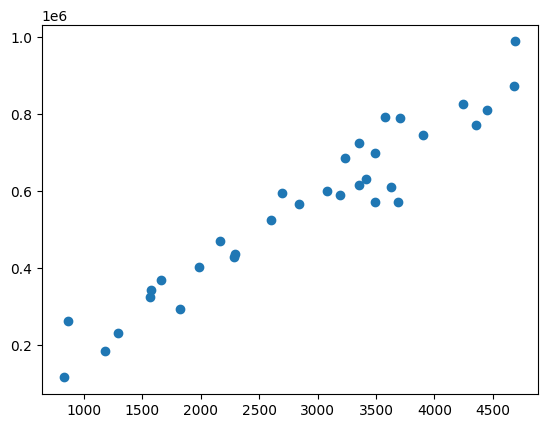

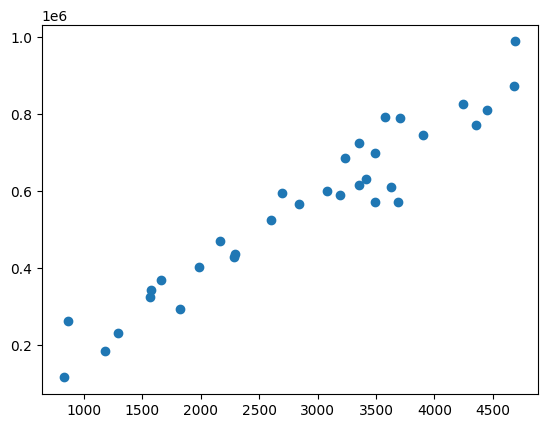

In [72]:
# Plot Best Fit Line
plt.scatter(X_test['area'], y_test)

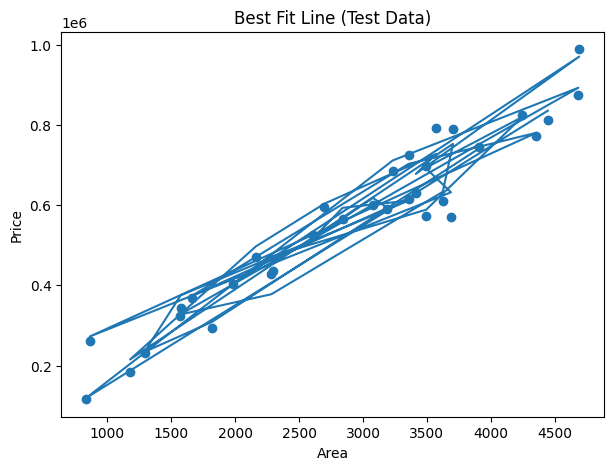

In [107]:
# ---- Plot Best Fit Line (Area vs Price) ----
# area_test = X_test['area'].reset_index()   # area column

# Sort values for smooth line
# sorted_idx = np.argsort(area_test)

plt.figure(figsize=(7,5))
plt.scatter(X_test['area'], y_test)
plt.plot(
    X_test['area'],
    y_test_preds)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Best Fit Line (Test Data)")

plt.show()

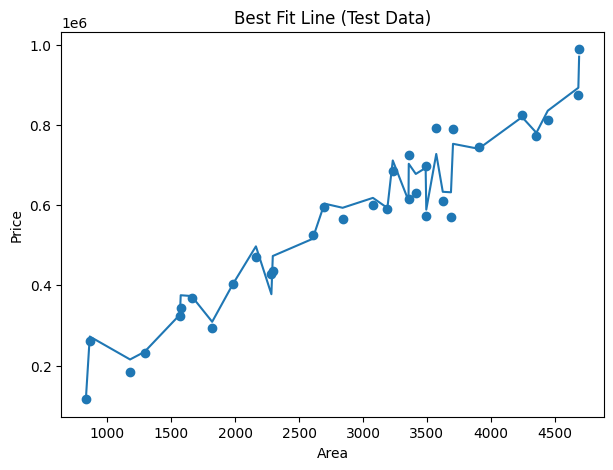

In [108]:
import numpy as np

plt.figure(figsize=(7,5))

# Scatter
plt.scatter(X_test['area'], y_test)

# Sort values
sorted_idx = np.argsort(X_test['area'])

plt.plot(
    X_test['area'].iloc[sorted_idx],
    y_test_preds[sorted_idx]
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Best Fit Line (Test Data)")

plt.show()

In [109]:
area_range = np.linspace(X['area'].min(), X['area'].max(), 100)

# Create mean values for other features
bed_mean = X['bedrooms'].mean()
age_mean = X['age'].mean()

X_line = np.column_stack([
    area_range,
    np.full(100, bed_mean),
    np.full(100, age_mean)
])

y_line = model.predict(X_line)

plt.scatter(X_test['area'], y_test)
plt.plot(area_range, y_line)

plt.show()

NameError: name 'model' is not defined